In [ ]:
import os

print("Root Input:")
print(os.listdir("/kaggle/input"))

print("\nCompetitions Folder:")
print(os.listdir("/kaggle/input/competitions"))

print("\nHouse Prices Folder:")
print(os.listdir("/kaggle/input/competitions/house-prices-advanced-regression-techniques"))

print("\nDogs vs Cats Folder:")
print(os.listdir("/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition"))

Dataset Shape: (1460, 81)
After Encoding Shape: (1460, 244)

CV RMSE: 0.1780197716709767

Test RMSE: 0.16116111958156032
Test R2: 0.8608179150586813


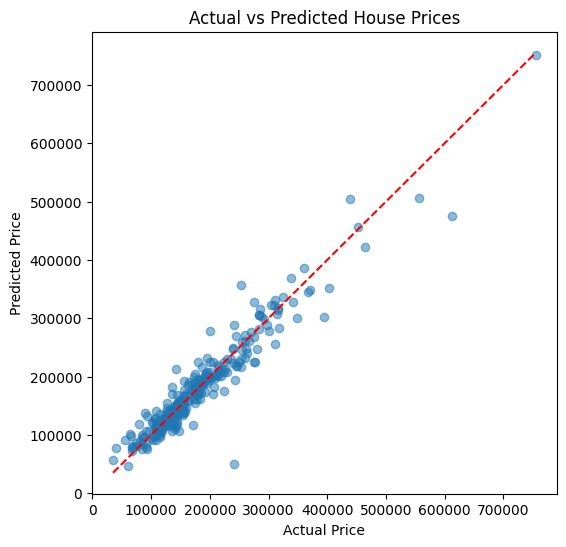

In [3]:
# ============================================================
# TASK 1: House Price Prediction
# Regression using Ridge + Log Transform
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ================= LOAD DATA =================
DATA_PATH = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

# ================= LOG TRANSFORM TARGET =================
df["SalePrice"] = np.log1p(df["SalePrice"])

# ================= FEATURE SELECTION =================
X = df.drop(["SalePrice", "Id"], axis=1)
y = df["SalePrice"]

# ================= HANDLE MISSING VALUES =================
# Numerical → median
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Categorical → most frequent
cat_cols = X.select_dtypes(include=["object"]).columns
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("After Encoding Shape:", X.shape)

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================= SCALE =================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================= MODEL =================
model = Ridge(alpha=10)
model.fit(X_train, y_train)

# ================= CROSS VALIDATION =================
cv_scores = cross_val_score(
    model, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

print("\nCV RMSE:", -cv_scores.mean())

# ================= EVALUATE =================
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTest RMSE:", rmse)
print("Test R2:", r2)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

# ================= PLOT =================
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

Dataset Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Summary Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.

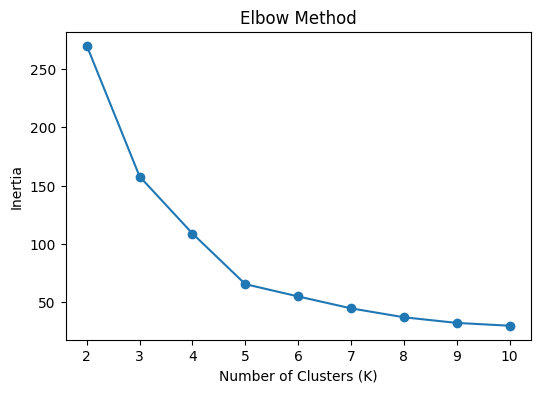


Silhouette Scores:
K=2 → 0.3213
K=3 → 0.4666
K=4 → 0.4939
K=5 → 0.5547
K=6 → 0.5399
K=7 → 0.5281
K=8 → 0.4552
K=9 → 0.4571
K=10 → 0.4432

Best K: 5

Cluster Centers:
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043

Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                            
0                 55.296296               49.518519              81
1                 86.538462               82.128205              39
2                 25.727273               79.363636              22
3                 88.200000               17.114286              35
4                 26.304348               20.913043              23


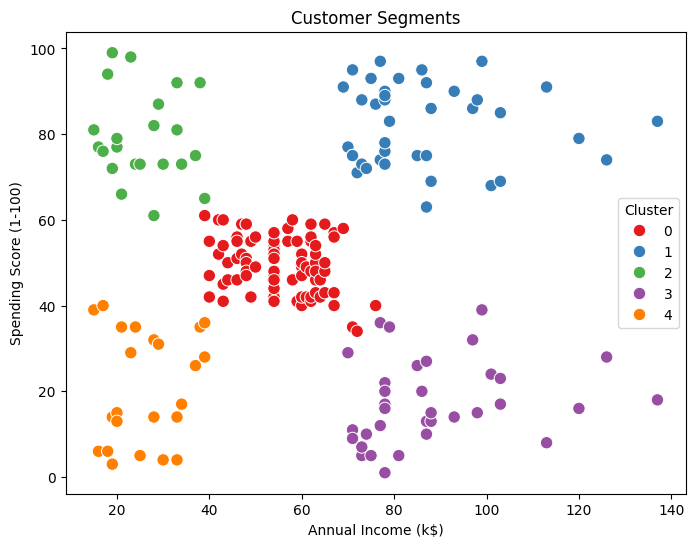

In [4]:
# ============================================================
# TASK 2: Customer Segmentation using KMeans Clustering
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ================= LOAD DATA =================
DATA_PATH = "/kaggle/input/datasets/abdulbaseerhammad/ml-tasks-datasets/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print(df.head())

# ================= BASIC INFO =================
print("\nSummary Statistics:")
print(df.describe())

# ================= FEATURE SELECTION =================
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

# ================= SCALE =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= ELBOW METHOD =================
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# ================= SILHOUETTE SCORE =================
print("\nSilhouette Scores:")
best_k = 0
best_score = -1

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} → {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print("\nBest K:", best_k)

# ================= FINAL MODEL =================
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# ================= CLUSTER CENTERS =================
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)

print("\nCluster Centers:")
print(centers_df)

# ================= CLUSTER SUMMARY =================
summary = df.groupby("Cluster")[features].mean()
summary["Customer Count"] = df["Cluster"].value_counts().sort_index()

print("\nCluster Summary:")
print(summary)

# ================= VISUALIZATION =================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=80
)
plt.title("Customer Segments")
plt.show()

In [6]:
import numpy as np
from PIL import Image
from tqdm import tqdm
import random

IMG_SIZE = (64, 64)
MAX_PER_CLASS = 1000
DATA_DIR = "/kaggle/working/dogs-vs-cats/train"

X = []
y = []

for label, animal in enumerate(["cat", "dog"]):
    files = [f for f in os.listdir(DATA_DIR) if f.startswith(animal)]
    random.shuffle(files)
    
    for fname in tqdm(files[:MAX_PER_CLASS], desc=f"Loading {animal}s"):
        try:
            img = Image.open(os.path.join(DATA_DIR, fname))
            img = img.convert("RGB").resize(IMG_SIZE)
            X.append(np.array(img).flatten())
            y.append(label)
        except:
            continue

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Loading dogs: 100%|██████████| 1000/1000 [00:02<00:00, 450.58it/s]

Dataset shape: (2000, 12288)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1600, 12288)
Test size: (400, 12288)


In [8]:
from sklearn.svm import SVC

print("Training SVM...")

svm = SVC(kernel="rbf", C=10, gamma="scale")
svm.fit(X_train, y_train)

print("Training complete.")

Training SVM...
Training complete.



Classification Report:
              precision    recall  f1-score   support

         Cat       0.55      0.56      0.56       200
         Dog       0.55      0.54      0.55       200

    accuracy                           0.55       400
   macro avg       0.55      0.55      0.55       400
weighted avg       0.55      0.55      0.55       400



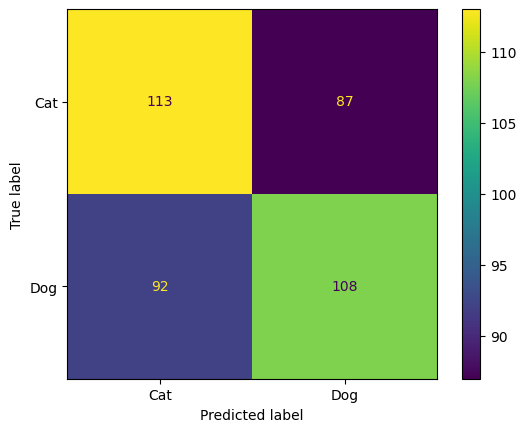

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = svm.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Cat", "Dog"]).plot()
plt.show()